# Caregiver Cluster Analysis for the Autism Acceptability Study

This notebook analyzes the caregiver survey using the attached REDCap CSV files only: the raw export, the labeled export, and the cleaned complete-case dataset.

## Notebook goals
- Build a reproducible analysis pipeline directly from the survey CSV files.
- Preserve the study logic: TFA constructs, Schwartz values, family background, and autism knowledge scoring.
- Document the variables, labels, and question text used in clustering and prediction.
- Focus on the primary outcome of whether parents would screen their 4-month-old child.

## Expected outputs
- A documented codebook linking variable names to question text.
- A cleaned analytic dataset derived from the attached CSV files.
- Cluster diagnostics and a real-data clustering solution.
- A predictive model for willingness to screen a 4-month-old child.

## Theory, Measurement, and Modeling Decisions

### What cluster analysis does in this study
Cluster analysis groups caregivers who answered the acceptability survey in similar ways, without using the 4-month screening outcome during model fitting. The goal is to identify recurring response patterns such as more supportive, more hesitant, or more burden-sensitive respondent profiles.

### Why K-means is an appropriate first model
K-means is a reasonable first-pass method here because many of the core TFA items behave like numeric survey scales and the resulting profiles are easy to summarize for a research audience.

### Core formulas

Euclidean distance between two caregivers $x$ and $y$ across $p$ features:

$$
d(x, y) = \sqrt{\sum_{j=1}^{p}(x_j - y_j)^2}
$$

Standardization of each feature before clustering:

$$
z = \frac{x - \mu}{\sigma}
$$

Cluster centroid for cluster $k$ with $n_k$ caregivers:

$$
\mu_k = \frac{1}{n_k}\sum_{i \in C_k} x_i
$$

Inertia or within-cluster sum of squares:

$$
\mathrm{WCSS} = \sum_{k=1}^{K}\sum_{i \in C_k}\lVert x_i - \mu_k \rVert^2
$$

Silhouette score for one caregiver:

$$
s = \frac{b-a}{\max(a,b)}
$$

where $a$ is the average distance to the caregiver's own cluster and $b$ is the average distance to the nearest competing cluster.

### Methodological choices used below
- Family-background variables are kept out of clustering and used for interpretation or supervised follow-up only.
- Ordinal items are aligned so larger values consistently represent greater screening support when used together.
- Direct 4-month screening outcome items are excluded from clustering to avoid leakage.
- The notebook documents the exact variables and question text used from the CSV files before fitting any models.

## REDCap Data Setup

> This section reads the attached REDCap CSV files, aligns the unlabeled and labeled exports, and prepares the complete-case survey subset used later in the notebook.

In [7]:
from pathlib import Path
from urllib.parse import quote
import pandas as pd
from IPython.display import Markdown, display

EXPECTED_FILES = {
    'raw': 'InfantAutismScreenin-FullDataset_DATA_2026-01-20_0940.csv',
    'labeled': 'InfantAutismScreenin-FullDataset_DATA_LABELS_2026-01-20_0940.csv',
    'clean_complete': 'cleaned_autism_study_data.csv',
}

REPO_BASES = [
    'https://raw.githubusercontent.com/namo507/esd-redcap-metadata-watcher/main/Caregiver%20Project',
    'https://raw.githubusercontent.com/namo507/esd-redcap-metadata-watcher/master/Caregiver%20Project',
]

def resolve_project_file(filename: str) -> str:
    cwd = Path.cwd()
    home = Path.home()
    candidate_dirs = [
        cwd,
        cwd / 'Caregiver Project',
        home / 'Downloads',
        home / 'Documents',
        *list(cwd.parents)[:3],
    ]
    seen = set()
    for directory in candidate_dirs:
        directory = directory.resolve()
        if directory in seen or not directory.exists():
            continue
        seen.add(directory)
        for candidate in (directory / filename, directory / 'Caregiver Project' / filename):
            if candidate.exists():
                return str(candidate)
    matches = list((home / 'Downloads').glob(filename))
    if matches:
        return str(matches[0])
    encoded_name = quote(filename)
    for base in REPO_BASES:
        url = f'{base}/{encoded_name}'
        try:
            pd.read_csv(url, nrows=0)
            return url
        except Exception:
            continue
    raise FileNotFoundError(f'Could not resolve {filename} from {cwd}, Downloads, or repository raw URLs.')

paths = {key: resolve_project_file(name) for key, name in EXPECTED_FILES.items()}

raw_export_df = pd.read_csv(paths['raw'])
labeled_export_df = pd.read_csv(paths['labeled'])
clean_complete_labeled_df = pd.read_csv(paths['clean_complete'])

analysis_question_limit = raw_export_df.columns.get_loc('tfa_complete') + 1
question_map = dict(
    zip(
        raw_export_df.columns[:analysis_question_limit],
        labeled_export_df.columns[:analysis_question_limit],
    )
)
codebook_df = pd.DataFrame({
    'variable_name': raw_export_df.columns[:analysis_question_limit],
    'question_text': labeled_export_df.columns[:analysis_question_limit],
})

clean_record_col = clean_complete_labeled_df.columns[0]
clean_record_ids = pd.to_numeric(clean_complete_labeled_df[clean_record_col], errors='coerce').dropna().astype(int)
real_df = raw_export_df.loc[raw_export_df['record_id'].isin(clean_record_ids)].copy()
real_df = real_df.sort_values('record_id').reset_index(drop=True)

target_question = question_map['tfa_free_screen']
target_value_map = (
    pd.DataFrame({
        'raw_value': raw_export_df['tfa_free_screen'],
        'response_label': labeled_export_df.iloc[:, raw_export_df.columns.get_loc('tfa_free_screen')],
    })
    .dropna()
    .drop_duplicates()
    .sort_values('raw_value')
    .reset_index(drop=True)
)
target_value_map['raw_value'] = pd.to_numeric(target_value_map['raw_value'], errors='coerce').astype('Int64')

display(Markdown('### File alignment check'))
display(pd.DataFrame({
    'dataset': ['raw_export', 'labeled_export', 'clean_complete_labeled', 'real_complete_case_subset'],
    'rows': [len(raw_export_df), len(labeled_export_df), len(clean_complete_labeled_df), len(real_df)],
    'columns': [raw_export_df.shape[1], labeled_export_df.shape[1], clean_complete_labeled_df.shape[1], real_df.shape[1]],
    'resolved_source': [paths['raw'], paths['labeled'], paths['clean_complete'], 'derived from clean record IDs'],
}))

display(Markdown('### Question-mapping coverage used in this notebook'))
display(Markdown(f'Automatic label alignment is applied through **tfa_complete**, which safely covers the clustering variables and the 4-month screening target.'))

display(Markdown('### Target question used for uptake modeling'))
display(Markdown(f'**tfa_free_screen**: {target_question}'))
display(target_value_map)

display(Markdown('### First pass codebook preview'))
display(codebook_df.head(12))

### File alignment check

,dataset,rows,columns,resolved_source
0,raw_export,177,183,C:\Users\homekit-tigger\Downloads\InfantAutism...
1,labeled_export,177,186,C:\Users\homekit-tigger\Downloads\InfantAutism...
2,clean_complete_labeled,135,186,C:\Users\homekit-tigger\Downloads\cleaned_auti...
3,real_complete_case_subset,135,183,derived from clean record IDs


### Question-mapping coverage used in this notebook

Automatic label alignment is applied through **tfa_complete**, which safely covers the clustering variables and the 4-month screening target.

### Target question used for uptake modeling

**tfa_free_screen**: If YOU were offered a free autism screening test  for YOUR 4-month-old baby, would you do it?

,raw_value,response_label
0,0,Definitely no
1,1,Probably not
2,2,I'm not sure
3,3,Probably
4,4,Definitely yes


### First pass codebook preview

,variable_name,question_text
0,record_id,Record ID
1,get_time_fif,"get_time_fif, get completion time for survey ..."
2,get_min_fif,"get_min_fif, calc 'minutes' (or hours and mi..."
3,get_secs_fif,"get_secs_fif, calc remainder of survey comple..."
4,format_secs_fif,"format_secs_fif, if get_secs_fif < 10, pad wi..."
5,format_hour_fif,"format_hour_fif, check for entry time = 60+ m..."
6,format_min_fif,"format_min_fif If time elapsed > 1 hour, get ..."
7,format_min_from_hr_fif,format_min_from_hr_fif If time elapsed > 1 ho...
8,survey_time_fif,"survey_time_fif, survey completion time, conc..."
9,fif_num_children,How many children do you have?


## Figure Output Setup

> This section creates a dedicated Caregiver output folder and defines a helper that saves each figure as both PNG and PDF with manuscript-style filenames.

In [20]:
from pathlib import Path
from IPython.display import Markdown, display

figure_output_dir = Path(paths['clean_complete']).resolve().parent / 'Caregiver Outputs'
figure_output_dir.mkdir(parents=True, exist_ok=True)

def export_figure(fig, stem: str):
    saved_paths = []
    for suffix in ('png', 'pdf'):
        target = figure_output_dir / f'{stem}.{suffix}'
        fig.savefig(target, bbox_inches='tight', facecolor='white')
        saved_paths.append(target)
    return saved_paths

display(Markdown(f'### Figure output directory\nFigures will be exported to **{figure_output_dir}** as both PNG and PDF files.'))

### Figure output directory
Figures will be exported to **C:\Users\homekit-tigger\Downloads\Caregiver Outputs** as both PNG and PDF files.

## Variable Inventory and 4-Month Screening Target

> The tables below document exactly which variables are used for clustering and which additional variables are used for uptake prediction. Direct outcome-leakage items are intentionally excluded from clustering.

In [8]:
import numpy as np
from IPython.display import Markdown, display

analysis_df_real = real_df.copy()

cluster_feature_groups = {
    'emotion_response': [
        'tfa_surprised', 'tfa_disgusted', 'tfa_scared', 'tfa_angry',
        'tfa_sad', 'tfa_happy', 'tfa_trusting', 'tfa_comfortable',
    ],
    'burden_feasibility': [
        'tfa_difficult', 'tfa_doable', 'tfa_separate_difficult',
        'tfa_separate_doable', 'tfa_series_difficult', 'tfa_series_doable',
    ],
    'test_modality_acceptance': [
        'tfa_mri', 'tfa_eeg', 'tfa_video', 'tfa_blood',
        'tfa_saliva', 'tfa_heart', 'tfa_observe',
    ],
    'utility_ethics': [
        'tfa_screen_accuracy', 'tfa_future', 'tfa_overall_help',
        'tfa_scan_any', 'tfa_scan_mine',
    ],
    'consequence_positive': [
        'tfa_believe_positive', 'tfa_interact_positive', 'tfa_gain_vs_loss', 'tfa_regret',
    ],
    'consequence_negative': [
        'tfa_believe_negative', 'tfa_interact_negative', 'tfa_gain_vs_loss_neg', 'tfa_regret_pos',
    ],
    'schwartz_values': [
        'conformity_val', 'tradition_val', 'benevolence_val', 'universalism_val',
        'self_direction_val', 'stimulation_val', 'hedonism_val', 'achievement_val',
        'power_val', 'security_val',
    ],
}

cluster_feature_vars = [
    variable
    for group_vars in cluster_feature_groups.values()
    for variable in group_vars
]

predictor_only_vars = [
    'fif_num_autistic', 'fif_autism_yn', 'fif_work_autistic', 'fif_knowledge',
    'fif_child_needs', 'fif_premature', 'fif_num_children',
]

knowledge_answer_key = {
    'tfa_behavior_age': 3,
    'tfa_autistic_us': 2,
    'tfa_mult_kids_odds': 3,
}

all_numeric_inputs = sorted(set(cluster_feature_vars + predictor_only_vars + list(knowledge_answer_key)))
for variable in all_numeric_inputs + ['tfa_free_screen']:
    analysis_df_real[variable] = pd.to_numeric(analysis_df_real[variable], errors='coerce')

for variable, correct_value in knowledge_answer_key.items():
    analysis_df_real[f'{variable}_correct'] = (analysis_df_real[variable] == correct_value).astype(int)

analysis_df_real['autism_knowledge_score'] = analysis_df_real[[
    f'{variable}_correct' for variable in knowledge_answer_key
]].sum(axis=1)

cluster_feature_vars = cluster_feature_vars + ['autism_knowledge_score']
target_label_lookup = dict(zip(target_value_map['raw_value'].astype(int), target_value_map['response_label']))
analysis_df_real['screen_4mo_label'] = analysis_df_real['tfa_free_screen'].map(target_label_lookup)
analysis_df_real['screen_4mo_binary'] = analysis_df_real['tfa_free_screen'].isin([3, 4]).astype(int)
analysis_df_real['screen_4mo_binary_label'] = np.where(
    analysis_df_real['screen_4mo_binary'].eq(1),
    'Would screen at 4 months',
    'Would not / unsure',
)

leakage_exclusions = [
    'tfa_free_screen', 'tfa_test_choice', 'tfa_explain_freescreen',
    'tfa_test_today', 'tfa_test_future', 'tfa_whylater', 'tfa_feedback_other',
    'screen_4mo_label', 'screen_4mo_binary', 'screen_4mo_binary_label',
]

group_lookup = {
    variable: group_name
    for group_name, group_vars in cluster_feature_groups.items()
    for variable in group_vars
}
group_lookup['autism_knowledge_score'] = 'knowledge_derived'

inventory_rows = []
for variable in cluster_feature_vars:
    question_text = 'Derived from the three autism knowledge questions.' if variable == 'autism_knowledge_score' else question_map.get(variable, 'Question label not auto-aligned in the shared survey block.')
    inventory_rows.append({
        'variable_name': variable,
        'role': 'cluster_feature',
        'feature_group': group_lookup.get(variable, 'derived'),
        'question_text': question_text,
    })

for variable in predictor_only_vars:
    inventory_rows.append({
        'variable_name': variable,
        'role': 'predictor_only',
        'feature_group': 'family_background',
        'question_text': question_map.get(variable, 'Question label not auto-aligned in the shared survey block.'),
    })

inventory_df = pd.DataFrame(inventory_rows)

target_distribution = (
    analysis_df_real['screen_4mo_label']
    .value_counts(dropna=False)
    .rename_axis('response_label')
    .to_frame('n')
)
target_distribution['pct'] = (target_distribution['n'] / len(analysis_df_real) * 100).round(1)

display(Markdown('### Target construction'))
display(Markdown("Positive class = **Probably** or **Definitely yes** on `tfa_free_screen`."))
display(target_distribution)

display(Markdown('### Cluster and prediction variable inventory'))
display(inventory_df)

display(Markdown('### Variables intentionally excluded from clustering to avoid direct leakage'))
display(pd.DataFrame({'excluded_variable': leakage_exclusions}))

print(f'Real analysis sample size: {len(analysis_df_real)}')
print(f'Cluster feature count: {len(cluster_feature_vars)}')
print(f'Predictor-only variable count: {len(predictor_only_vars)}')

### Target construction

Positive class = **Probably** or **Definitely yes** on `tfa_free_screen`.

,n,pct
response_label,,
Definitely yes,69,51.1
Probably,33,24.4
I'm not sure,15,11.1
Probably not,10,7.4
NaN,4,3.0
Definitely no,4,3.0


### Cluster and prediction variable inventory

,variable_name,role,feature_group,question_text
0,tfa_surprised,cluster_feature,emotion_response,Surprised
1,tfa_disgusted,cluster_feature,emotion_response,Disgusted
2,tfa_scared,cluster_feature,emotion_response,Scared
3,tfa_angry,cluster_feature,emotion_response,Angry
4,tfa_sad,cluster_feature,emotion_response,Sad
5,tfa_happy,cluster_feature,emotion_response,Happy
6,tfa_trusting,cluster_feature,emotion_response,Trusting (confident in doctor)
7,tfa_comfortable,cluster_feature,emotion_response,Comfortable
8,tfa_difficult,cluster_feature,burden_feasibility,How difficult would it be to spend an extra 15...
9,tfa_doable,cluster_feature,burden_feasibility,How doable would it be?


### Variables intentionally excluded from clustering to avoid direct leakage

,excluded_variable
0,tfa_free_screen
1,tfa_test_choice
2,tfa_explain_freescreen
3,tfa_test_today
4,tfa_test_future
5,tfa_whylater
6,tfa_feedback_other
7,screen_4mo_label
8,screen_4mo_binary
9,screen_4mo_binary_label


Real analysis sample size: 135
Cluster feature count: 45
Predictor-only variable count: 7


## Real-Data Cluster Analysis

> Clustering is fit on the documented feature set above, excluding the direct free-screen outcome items. The table and plots below show how the recovered parent profiles line up with willingness to screen a 4-month-old.

### Chosen number of clusters: 2

,k,inertia,silhouette_score
0,2,4312.733104,0.096782
1,3,4088.103168,0.054050
2,4,3934.618823,0.055945
3,5,3806.569657,0.045713
4,6,3683.769011,0.039954


,cluster_label,n,pct_of_sample,screen_yes_rate,mean_mri_acceptance,mean_video_acceptance,mean_overall_help,mean_scan_any,mean_knowledge,mean_trusting,mean_angry
0,High-Trust Supporters,67,63.2,0.866,3.417910,6.208955,1.507463,1.477612,1.298507,4.208955,1.074627
1,Cautious Supporters,39,36.8,0.692,2.794872,5.179487,1.897436,2.179487,1.384615,3.512821,1.205128


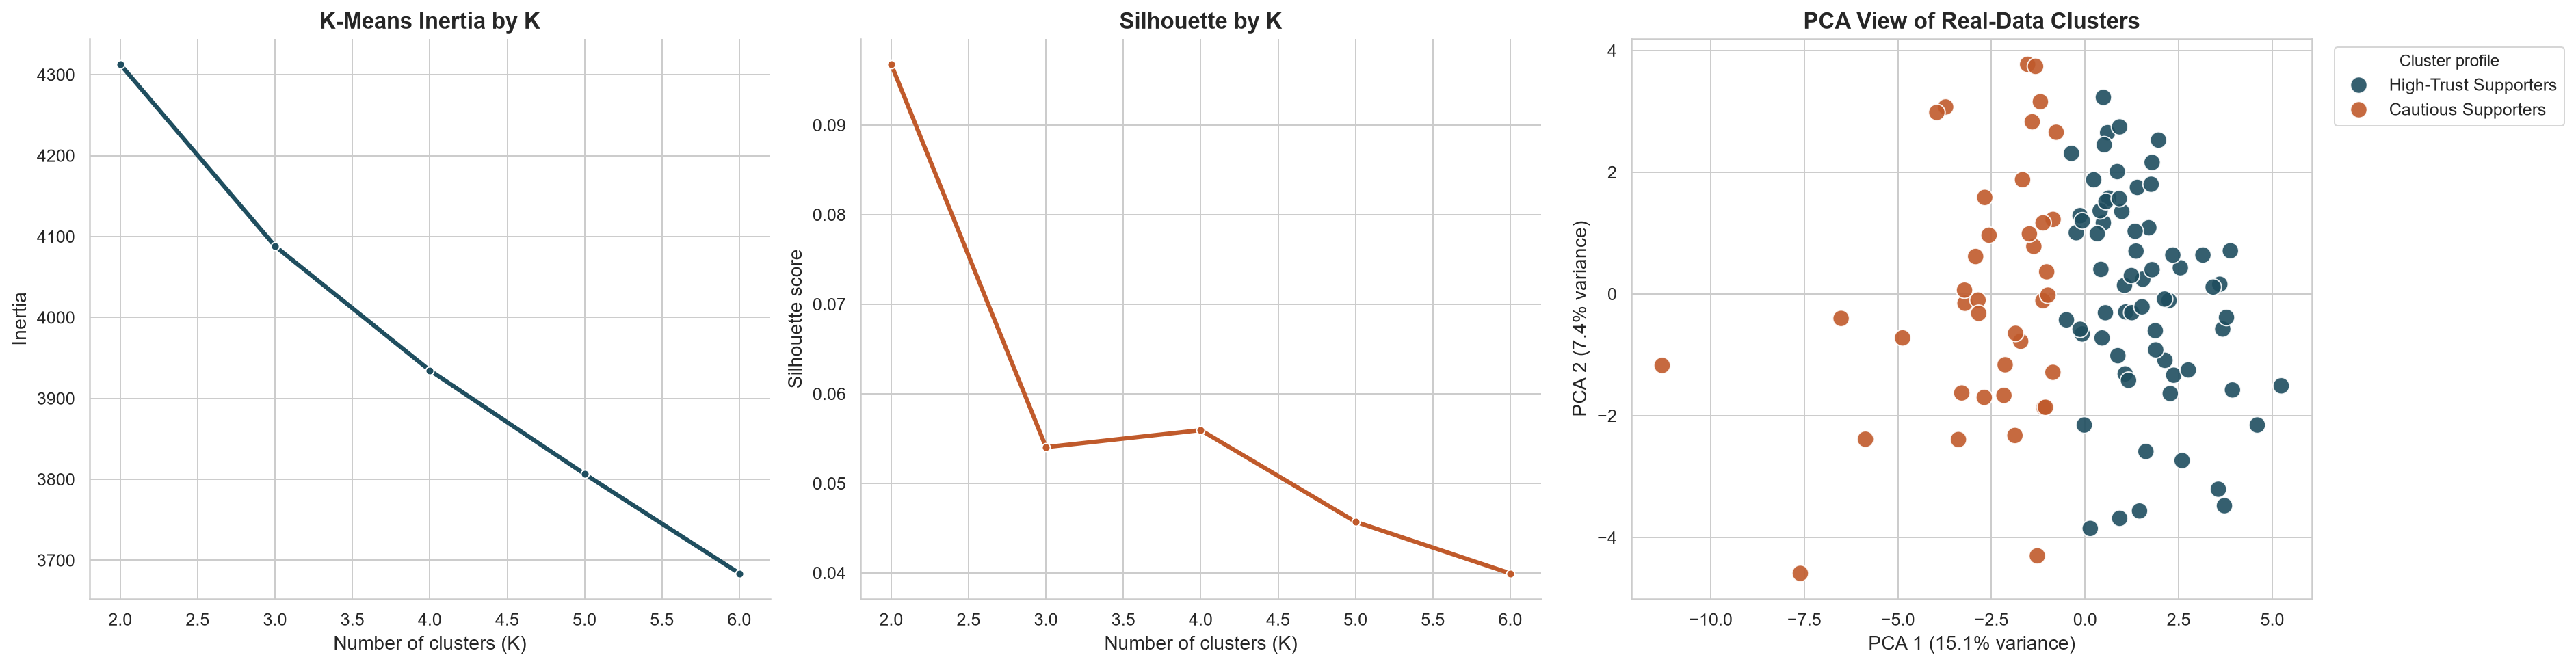

**Interpretation.** The real data favor a two-cluster solution. The higher-uptake profile, **High-Trust Supporters**, shows greater trust and greater openness to screening, while **Cautious Supporters** remain broadly supportive but are less receptive to more intensive testing. This figure was exported to the Caregiver Outputs folder as `supplement_figure_k_selection_and_pca` in both PNG and PDF formats.

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

cluster_df_real = analysis_df_real.dropna(subset=cluster_feature_vars + ['screen_4mo_binary']).copy()
X_cluster = cluster_df_real[cluster_feature_vars].copy()

scaler_real = StandardScaler()
X_cluster_scaled = scaler_real.fit_transform(X_cluster)

cluster_diagnostics = []
for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = model.fit_predict(X_cluster_scaled)
    cluster_diagnostics.append({
        'k': k,
        'inertia': model.inertia_,
        'silhouette_score': silhouette_score(X_cluster_scaled, labels),
    })

cluster_diagnostics_df = pd.DataFrame(cluster_diagnostics)
best_k_real = int(cluster_diagnostics_df.loc[cluster_diagnostics_df['silhouette_score'].idxmax(), 'k'])

kmeans_real = KMeans(n_clusters=best_k_real, random_state=42, n_init=50)
cluster_df_real['cluster_raw'] = kmeans_real.fit_predict(X_cluster_scaled)

cluster_summary_real = (
    cluster_df_real.groupby('cluster_raw').agg(
        n=('cluster_raw', 'size'),
        screen_yes_rate=('screen_4mo_binary', 'mean'),
        mean_mri_acceptance=('tfa_mri', 'mean'),
        mean_video_acceptance=('tfa_video', 'mean'),
        mean_overall_help=('tfa_overall_help', 'mean'),
        mean_scan_any=('tfa_scan_any', 'mean'),
        mean_knowledge=('autism_knowledge_score', 'mean'),
        mean_trusting=('tfa_trusting', 'mean'),
        mean_angry=('tfa_angry', 'mean'),
    )
    .sort_values('screen_yes_rate', ascending=False)
    .reset_index()
    .rename(columns={'cluster_raw': 'original_cluster'})
)
cluster_summary_real['pct_of_sample'] = (cluster_summary_real['n'] / len(cluster_df_real) * 100).round(1)

cluster_name_map = {}
if len(cluster_summary_real) == 2:
    cluster_name_map[cluster_summary_real.loc[0, 'original_cluster']] = 'High-Trust Supporters'
    cluster_name_map[cluster_summary_real.loc[1, 'original_cluster']] = 'Cautious Supporters'
else:
    highest_uptake_cluster = cluster_summary_real.loc[cluster_summary_real['screen_yes_rate'].idxmax(), 'original_cluster']
    lowest_uptake_cluster = cluster_summary_real.loc[cluster_summary_real['screen_yes_rate'].idxmin(), 'original_cluster']
    most_burdened_cluster = cluster_summary_real.loc[(cluster_summary_real['mean_mri_acceptance'] - cluster_summary_real['mean_video_acceptance']).idxmin(), 'original_cluster']
    cluster_name_map[highest_uptake_cluster] = 'High-Trust Supporters'
    cluster_name_map[lowest_uptake_cluster] = 'Burden-Conscious Skeptics'
    if most_burdened_cluster not in cluster_name_map:
        cluster_name_map[most_burdened_cluster] = 'Cautious Supporters'
    remaining_clusters = [cluster for cluster in cluster_summary_real['original_cluster'] if cluster not in cluster_name_map]
    fallback_names = ['Values-Driven Supporters', 'Selective Supporters', 'Moderate Supporters']
    for cluster, label in zip(remaining_clusters, fallback_names):
        cluster_name_map[cluster] = label

cluster_summary_real['cluster_label'] = cluster_summary_real['original_cluster'].map(cluster_name_map)
cluster_df_real['cluster_label'] = cluster_df_real['cluster_raw'].map(cluster_name_map)
cluster_summary_real['screen_yes_rate'] = cluster_summary_real['screen_yes_rate'].round(3)

pca_real = PCA(n_components=2, random_state=42)
pca_scores_real = pca_real.fit_transform(X_cluster_scaled)
cluster_df_real['pca_1'] = pca_scores_real[:, 0]
cluster_df_real['pca_2'] = pca_scores_real[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(21, 5.5))
sns.lineplot(data=cluster_diagnostics_df, x='k', y='inertia', marker='o', color='#1f4e5f', linewidth=2.5, ax=axes[0])
axes[0].set_title('K-Means Inertia by K', fontsize=13, weight='bold')
axes[0].set_xlabel('Number of clusters (K)')
axes[0].set_ylabel('Inertia')
sns.lineplot(data=cluster_diagnostics_df, x='k', y='silhouette_score', marker='o', color='#c05a2b', linewidth=2.5, ax=axes[1])
axes[1].set_title('Silhouette by K', fontsize=13, weight='bold')
axes[1].set_xlabel('Number of clusters (K)')
axes[1].set_ylabel('Silhouette score')
cluster_palette_real = dict(zip(cluster_summary_real['cluster_label'], sns.color_palette(['#1f4e5f', '#c05a2b', '#4c7a5a', '#9b6a3f'][:len(cluster_summary_real)])))
sns.scatterplot(data=cluster_df_real, x='pca_1', y='pca_2', hue='cluster_label', palette=cluster_palette_real, s=95, alpha=0.9, ax=axes[2])
axes[2].set_title('PCA View of Real-Data Clusters', fontsize=13, weight='bold')
axes[2].set_xlabel(f'PCA 1 ({pca_real.explained_variance_ratio_[0]:.1%} variance)')
axes[2].set_ylabel(f'PCA 2 ({pca_real.explained_variance_ratio_[1]:.1%} variance)')
axes[2].legend(title='Cluster profile', bbox_to_anchor=(1.02, 1), loc='upper left')
for axis in axes[:2]:
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
plt.tight_layout()
export_figure(fig, 'supplement_figure_k_selection_and_pca')

display(Markdown(f'### Chosen number of clusters: {best_k_real}'))
display(cluster_diagnostics_df)
display(cluster_summary_real[['cluster_label', 'n', 'pct_of_sample', 'screen_yes_rate', 'mean_mri_acceptance', 'mean_video_acceptance', 'mean_overall_help', 'mean_scan_any', 'mean_knowledge', 'mean_trusting', 'mean_angry']])
plt.show()
display(Markdown("**Interpretation.** The real data favor a two-cluster solution. The higher-uptake profile, **High-Trust Supporters**, shows greater trust and greater openness to screening, while **Cautious Supporters** remain broadly supportive but are less receptive to more intensive testing. This figure was exported to the Caregiver Outputs folder as `supplement_figure_k_selection_and_pca` in both PNG and PDF formats."))

## Predicting 4-Month Screening Uptake

> This section uses the cleaned labeled dataset for the supervised task so the model can keep the largest possible non-missing sample. The positive class remains **Probably** or **Definitely yes** on the free 4-month screening question.

In [22]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

rename_to_raw = {question_text: variable_name for variable_name, question_text in question_map.items()}
prediction_df_real = clean_complete_labeled_df.rename(columns=rename_to_raw).copy()

prediction_feature_vars = [
    variable for variable in (cluster_feature_vars + predictor_only_vars)
    if variable in prediction_df_real.columns
]

prediction_df_real = prediction_df_real[['record_id', 'tfa_free_screen'] + prediction_feature_vars].copy()
prediction_df_real = prediction_df_real[prediction_df_real['tfa_free_screen'].notna()].copy()
prediction_df_real['screen_4mo_binary'] = prediction_df_real['tfa_free_screen'].isin(['Probably', 'Definitely yes']).astype(int)

numeric_predictors = prediction_df_real[prediction_feature_vars].select_dtypes(include=['number']).columns.tolist()
categorical_predictors = [variable for variable in prediction_feature_vars if variable not in numeric_predictors]

X_pred = prediction_df_real[prediction_feature_vars]
y_pred = prediction_df_real['screen_4mo_binary']

prediction_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]),
            numeric_predictors,
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore')),
            ]),
            categorical_predictors,
        ),
    ]
)

logit_pipeline = Pipeline([
    ('preprocess', prediction_preprocessor),
    ('model', LogisticRegression(max_iter=5000, class_weight='balanced')),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    logit_pipeline,
    X_pred,
    y_pred,
    cv=cv,
    scoring=['roc_auc', 'accuracy', 'balanced_accuracy'],
    return_train_score=False,
 )

logit_pipeline.fit(X_pred, y_pred)
feature_names = logit_pipeline.named_steps['preprocess'].get_feature_names_out()
coefficients = logit_pipeline.named_steps['model'].coef_[0]
coefficient_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients),
}).sort_values('abs_coefficient', ascending=False)

cv_summary_df = pd.DataFrame({
    'metric': ['roc_auc', 'accuracy', 'balanced_accuracy'],
    'mean': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_balanced_accuracy'].mean(),
    ],
    'std': [
        cv_results['test_roc_auc'].std(),
        cv_results['test_accuracy'].std(),
        cv_results['test_balanced_accuracy'].std(),
    ],
}).round(3)

display(Markdown('### Predictive model sample and feature types'))
display(pd.DataFrame({
    'quantity': ['rows used for prediction', 'numeric predictors', 'categorical predictors'],
    'value': [len(prediction_df_real), len(numeric_predictors), len(categorical_predictors)],
}))

display(Markdown('### Cross-validated logistic model performance'))
display(cv_summary_df)

display(Markdown('### Strongest model coefficients by absolute size'))
display(coefficient_df.head(15))

### Predictive model sample and feature types

,quantity,value
0,rows used for prediction,131
1,numeric predictors,35
2,categorical predictors,16


### Cross-validated logistic model performance

,metric,mean,std
0,roc_auc,0.742,0.128
1,accuracy,0.687,0.104
2,balanced_accuracy,0.601,0.164


### Strongest model coefficients by absolute size

,feature,coefficient,abs_coefficient
33,num__fif_num_autistic,1.223238,1.223238
71,cat__tfa_scan_any_Ethically right,1.172023,1.172023
34,num__fif_num_children,-1.051760,1.051760
6,num__tfa_trusting,1.019790,1.019790
26,num__universalism_val,-0.941598,0.941598
42,cat__tfa_separate_difficult_Mostly easy,-0.908636,0.908636
74,cat__tfa_scan_any_Somewhat wrong,-0.820448,0.820448
9,num__tfa_eeg,0.769091,0.769091
80,cat__tfa_scan_mine_Very morally right (a must do),0.732797,0.732797
3,num__tfa_angry,-0.709140,0.709140


In [25]:
from IPython.display import Markdown, display

top_positive = coefficient_df.sort_values('coefficient', ascending=False).head(5)[['feature', 'coefficient']].copy()
top_negative = coefficient_df.sort_values('coefficient', ascending=True).head(5)[['feature', 'coefficient']].copy()

cluster_summary_markdown = '\n'.join(
    f"- {row.cluster_label}: n={int(row.n)}, uptake={row.screen_yes_rate:.1%}"
    for row in cluster_summary_real.itertuples()
 )
cluster_interpretation_lines = []
for row in cluster_summary_real.itertuples():
    if row.cluster_label == 'High-Trust Supporters':
        cluster_interpretation_lines.append(f"- {row.cluster_label}: larger profile with stronger trust in providers, greater openness to screening, and the higher uptake rate.")
    elif row.cluster_label == 'Cautious Supporters':
        cluster_interpretation_lines.append(f"- {row.cluster_label}: still broadly favorable to screening, but more hesitant and less open to intensive modalities than the higher-trust profile.")
    else:
        cluster_interpretation_lines.append(f"- {row.cluster_label}: distinct response profile with uptake of {row.screen_yes_rate:.1%}.")
cluster_interpretation_markdown = '\n'.join(cluster_interpretation_lines)
top_positive_markdown = '\n'.join(
    f"- {row.feature}: {row.coefficient:.3f}"
    for row in top_positive.itertuples()
 )
top_negative_markdown = '\n'.join(
    f"- {row.feature}: {row.coefficient:.3f}"
    for row in top_negative.itertuples()
 )

display(Markdown(f"""
## Real-Data Results Summary

**Main target question**
- If YOU were offered a free autism screening test for YOUR 4-month-old baby, would you do it?

**Observed uptake in the cleaned complete-case survey file**
- Definitely yes: 69 of 135 (51.1%)
- Probably: 33 of 135 (24.4%)
- Combined positive class for prediction: 102 of 135 (75.6%)

**Named real-data cluster profiles**
{cluster_summary_markdown}

**Plain-language interpretation**
{cluster_interpretation_markdown}

**Prediction baseline**
- Supervised modeling sample after dropping only missing target responses: {len(prediction_df_real)}
- Cross-validated ROC AUC: {cv_summary_df.loc[cv_summary_df['metric'] == 'roc_auc', 'mean'].iloc[0]:.3f}
- Cross-validated accuracy: {cv_summary_df.loc[cv_summary_df['metric'] == 'accuracy', 'mean'].iloc[0]:.3f}
- Cross-validated balanced accuracy: {cv_summary_df.loc[cv_summary_df['metric'] == 'balanced_accuracy', 'mean'].iloc[0]:.3f}

**Strongest positive coefficients in the logistic model**
{top_positive_markdown}

**Strongest negative coefficients in the logistic model**
{top_negative_markdown}

**Saved figure outputs**
- All figures are exported to the Caregiver Outputs folder in both PNG and PDF formats.
"""))


## Real-Data Results Summary

**Main target question**
- If YOU were offered a free autism screening test for YOUR 4-month-old baby, would you do it?

**Observed uptake in the cleaned complete-case survey file**
- Definitely yes: 69 of 135 (51.1%)
- Probably: 33 of 135 (24.4%)
- Combined positive class for prediction: 102 of 135 (75.6%)

**Named real-data cluster profiles**
- High-Trust Supporters: n=67, uptake=86.6%
- Cautious Supporters: n=39, uptake=69.2%

**Plain-language interpretation**
- High-Trust Supporters: larger profile with stronger trust in providers, greater openness to screening, and the higher uptake rate.
- Cautious Supporters: still broadly favorable to screening, but more hesitant and less open to intensive modalities than the higher-trust profile.

**Prediction baseline**
- Supervised modeling sample after dropping only missing target responses: 131
- Cross-validated ROC AUC: 0.742
- Cross-validated accuracy: 0.687
- Cross-validated balanced accuracy: 0.601

**Strongest positive coefficients in the logistic model**
- num__fif_num_autistic: 1.223
- cat__tfa_scan_any_Ethically right: 1.172
- num__tfa_trusting: 1.020
- num__tfa_eeg: 0.769
- cat__tfa_scan_mine_Very morally right (a must do): 0.733

**Strongest negative coefficients in the logistic model**
- num__fif_num_children: -1.052
- num__universalism_val: -0.942
- cat__tfa_separate_difficult_Mostly easy: -0.909
- cat__tfa_scan_any_Somewhat wrong: -0.820
- num__tfa_angry: -0.709

**Saved figure outputs**
- All figures are exported to the Caregiver Outputs folder in both PNG and PDF formats.


## Real-Data Summary Visualizations

> These figures summarize the real cluster solution and the 4-month screening prediction results in a format that is easier to interpret than the tables alone.

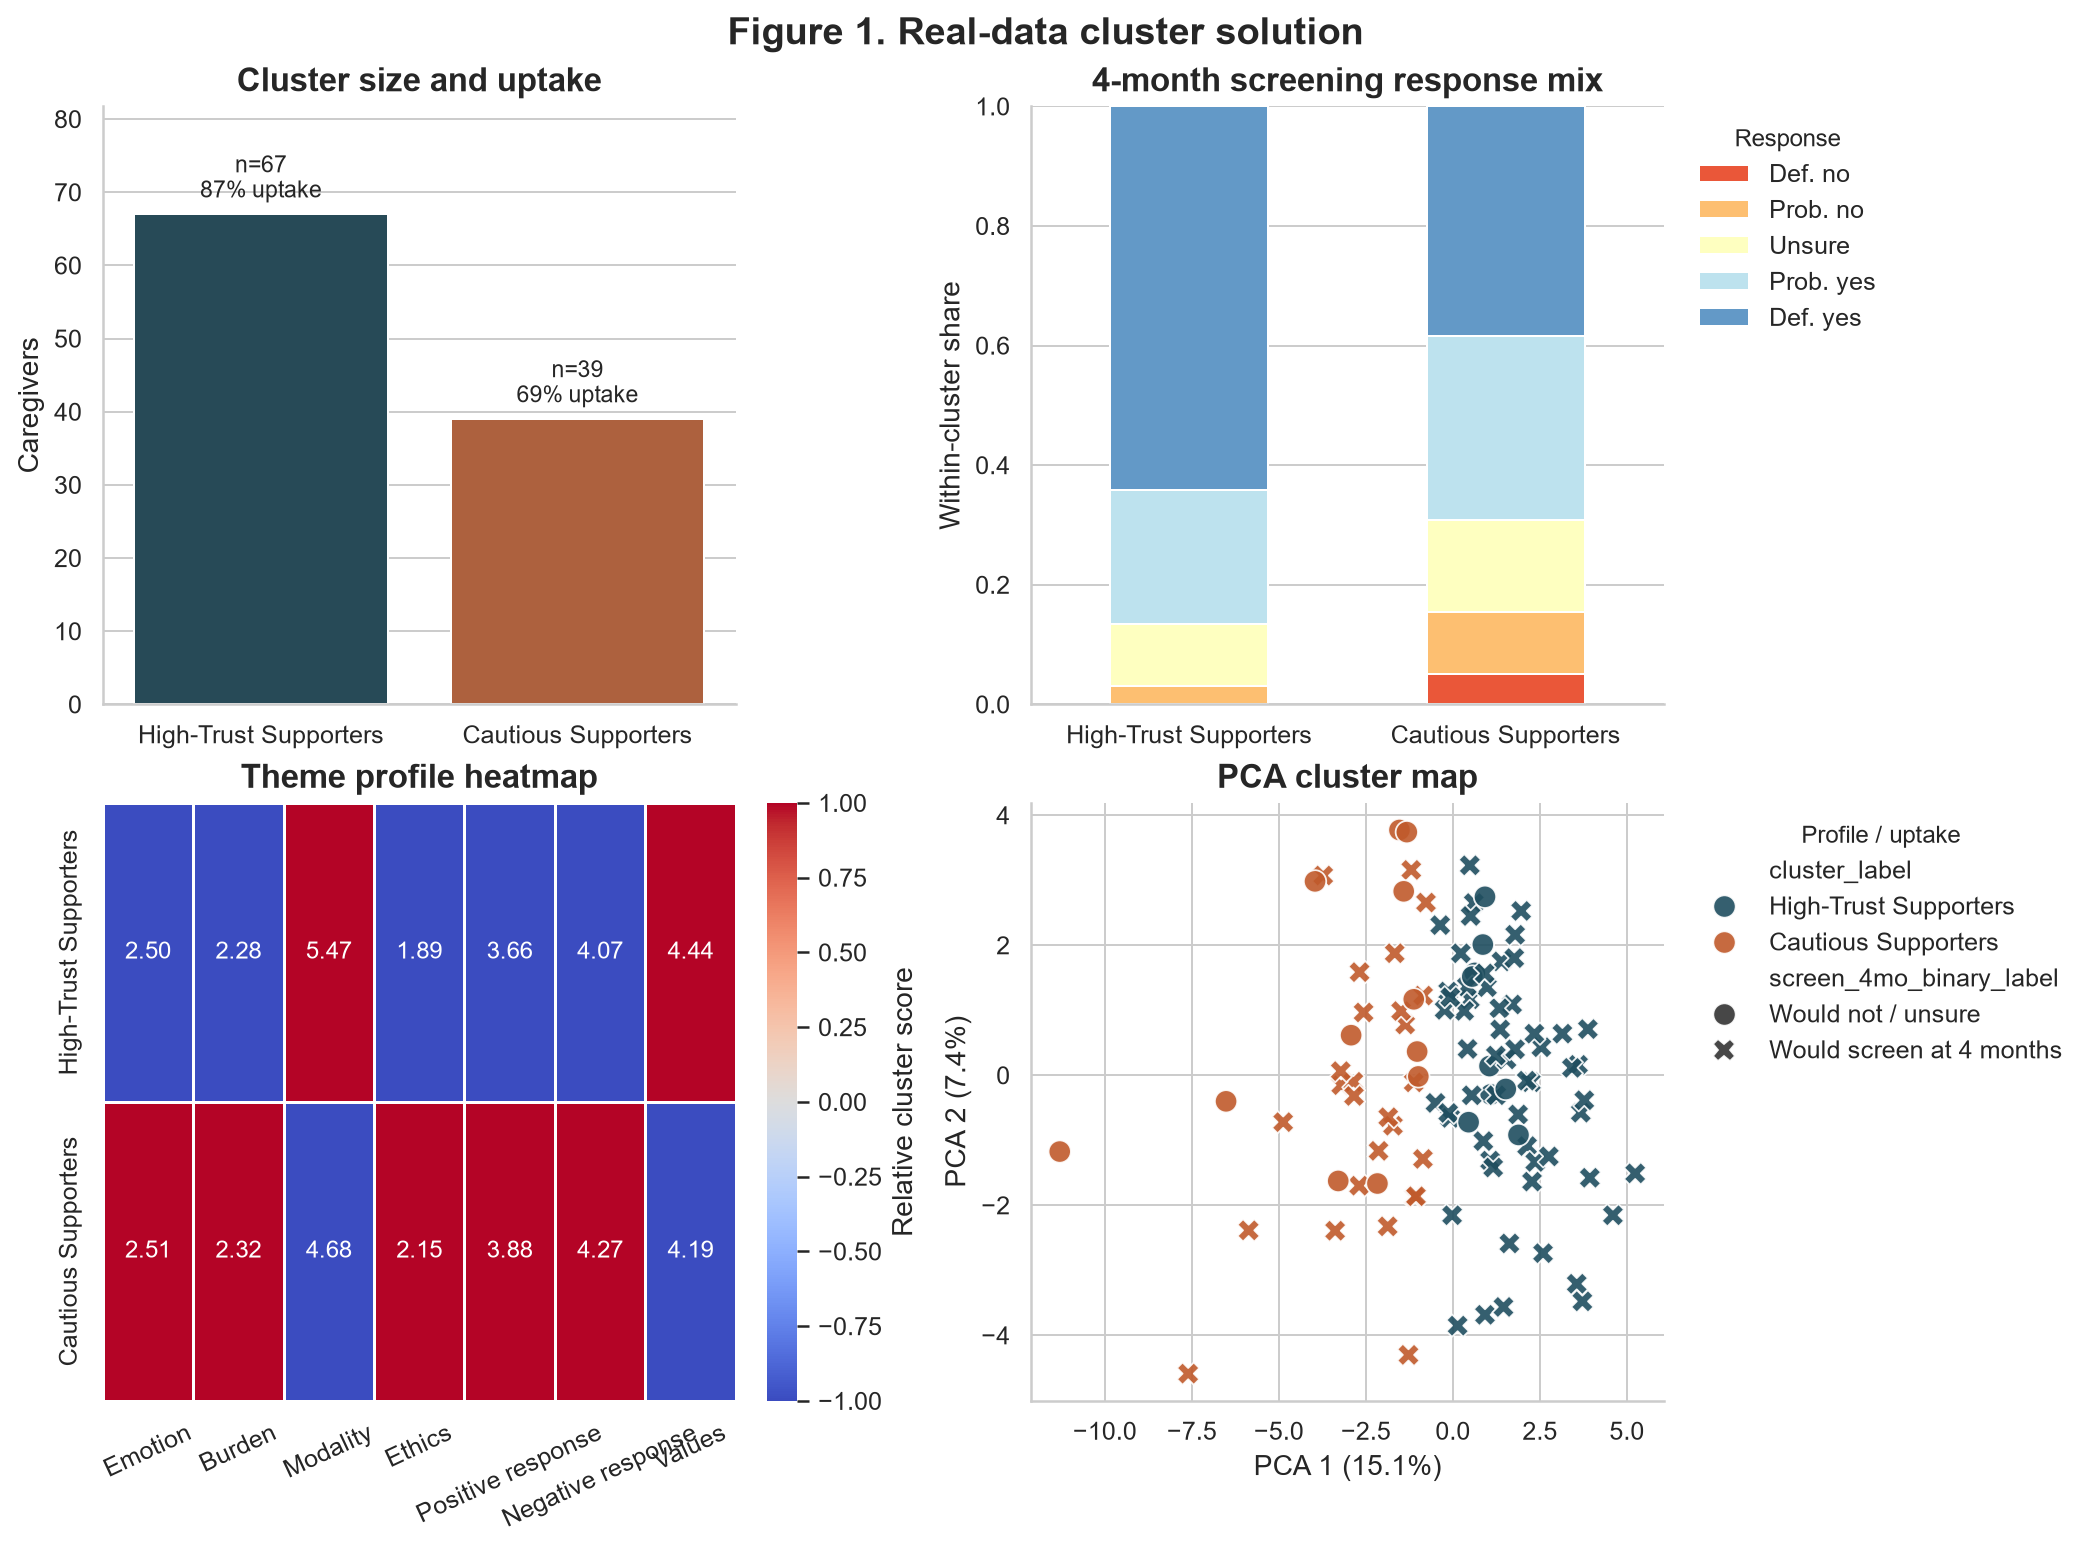

**Figure 1 interpretation.** The two real-data profiles differ most clearly in trust, willingness to screen, and openness to non-invasive and invasive testing. The **High-Trust Supporters** cluster is larger and shows consistently stronger uptake, whereas **Cautious Supporters** remain broadly favorable but less open to more intensive screening pathways. This figure was exported to the Caregiver Outputs folder as `figure_1_real_data_cluster_solution` in both PNG and PDF formats.

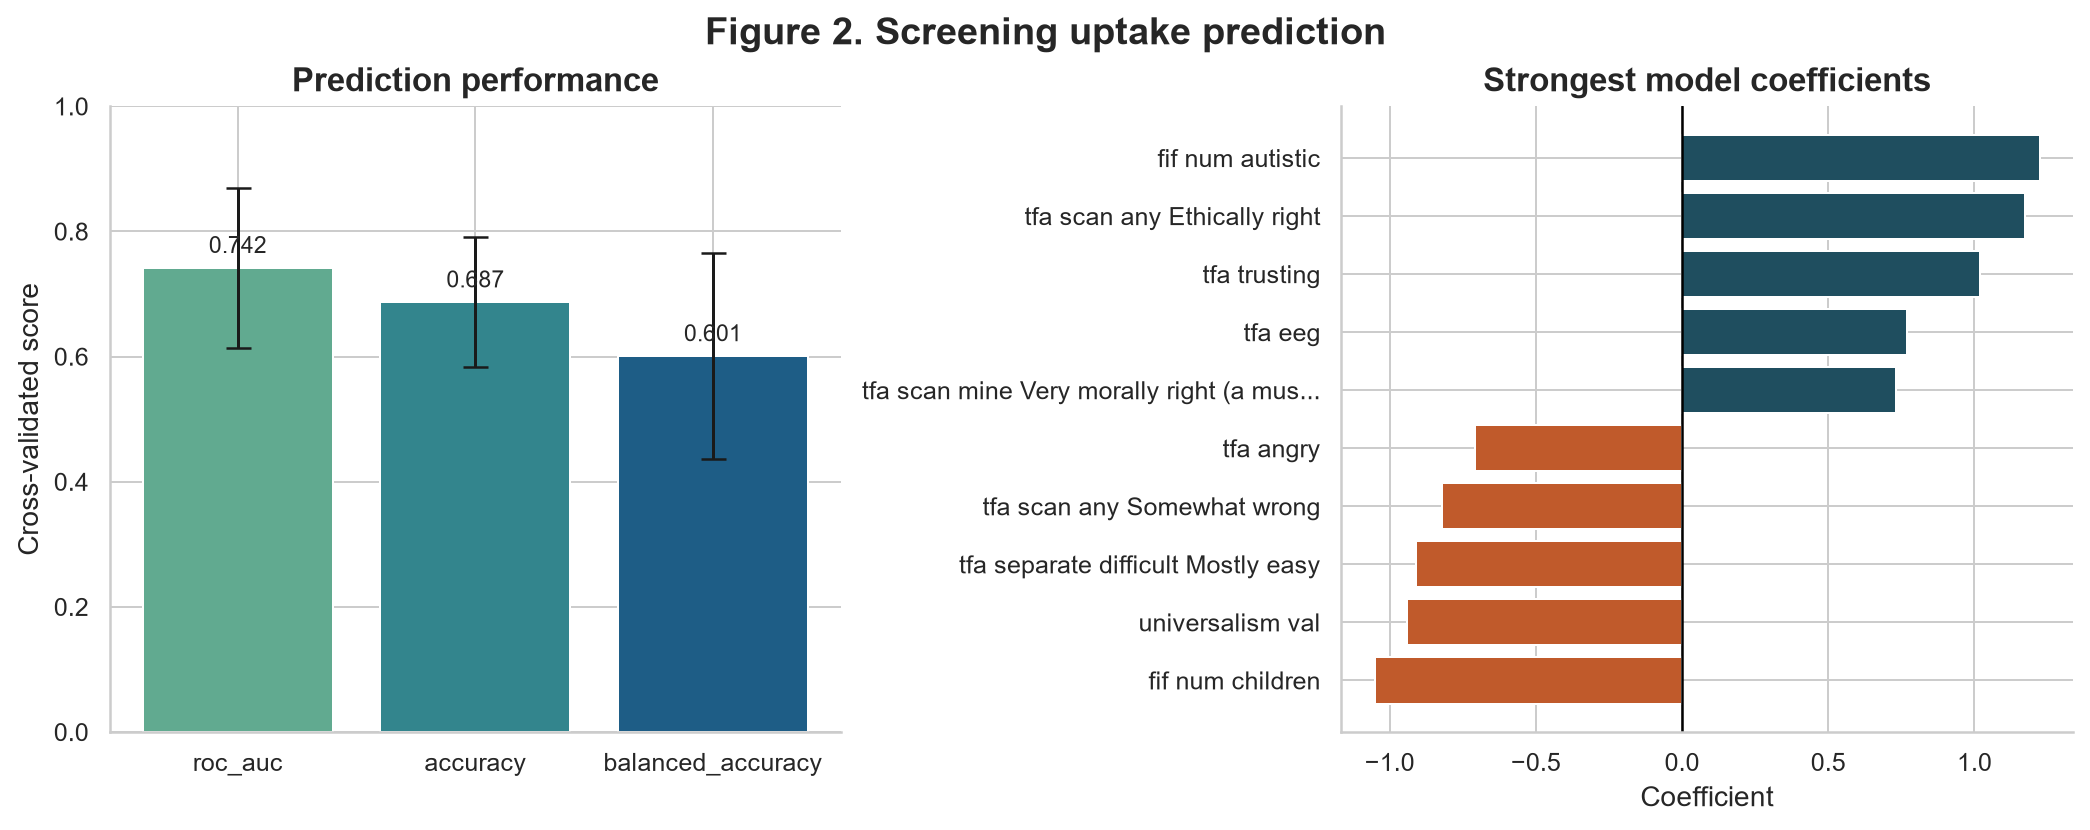

**Figure 2 interpretation.** Predictive performance is moderate rather than definitive, which is consistent with a complex attitudinal outcome. The strongest positive signals are prior autism experience, ethical approval of screening, and trust in providers, while negative coefficients reflect greater hesitation, lower ethical support, and weaker enthusiasm for intensive or uncertain testing. This figure was exported to the Caregiver Outputs folder as `figure_2_screening_uptake_prediction` in both PNG and PDF formats.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='paper')
plt.rcParams.update({
    'figure.dpi': 180,
    'savefig.dpi': 300,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

cluster_viz_df = cluster_df_real.copy()
cluster_viz_order = cluster_summary_real['cluster_label'].tolist()
cluster_palette = dict(zip(cluster_viz_order, ['#1f4e5f', '#c05a2b', '#4c7a5a', '#9b6a3f'][:len(cluster_viz_order)]))

theme_score_columns = {
    'Emotion': cluster_feature_groups['emotion_response'],
    'Burden': cluster_feature_groups['burden_feasibility'],
    'Modality': cluster_feature_groups['test_modality_acceptance'],
    'Ethics': cluster_feature_groups['utility_ethics'],
    'Positive response': cluster_feature_groups['consequence_positive'],
    'Negative response': cluster_feature_groups['consequence_negative'],
    'Values': cluster_feature_groups['schwartz_values'],
}

for label, columns in theme_score_columns.items():
    cluster_viz_df[label] = cluster_viz_df[columns].mean(axis=1)

theme_profile_df = (
    cluster_viz_df.groupby('cluster_label')[list(theme_score_columns)]
    .mean()
    .reindex(cluster_viz_order)
)
theme_profile_z = theme_profile_df.apply(
    lambda column: (column - column.mean()) / (column.std(ddof=0) if column.std(ddof=0) else 1),
    axis=0,
 )

response_order = ['Definitely no', 'Probably not', "I'm not sure", 'Probably', 'Definitely yes']
response_label_short = {
    'Definitely no': 'Def. no',
    'Probably not': 'Prob. no',
    "I'm not sure": 'Unsure',
    'Probably': 'Prob. yes',
    'Definitely yes': 'Def. yes',
}
response_mix_df = (
    cluster_viz_df.dropna(subset=['screen_4mo_label'])
    .groupby(['cluster_label', 'screen_4mo_label'])
    .size()
    .rename('n')
    .reset_index()
)
response_mix_df['screen_4mo_label'] = pd.Categorical(
    response_mix_df['screen_4mo_label'],
    categories=response_order,
    ordered=True,
 )
response_mix_pivot = (
    response_mix_df.pivot(index='cluster_label', columns='screen_4mo_label', values='n')
    .fillna(0)
    .reindex(cluster_viz_order)
)
response_mix_pct = response_mix_pivot.div(response_mix_pivot.sum(axis=1), axis=0)
response_mix_pct.columns = [response_label_short[column] for column in response_mix_pct.columns]

fig1, axes = plt.subplots(2, 2, figsize=(11.5, 8.5), constrained_layout=True)

sns.barplot(
    data=cluster_summary_real,
    x='cluster_label',
    y='n',
    hue='cluster_label',
    palette=cluster_palette,
    legend=False,
    ax=axes[0, 0],
 )
axes[0, 0].set_title('Cluster size and uptake')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Caregivers')
axes[0, 0].set_ylim(0, cluster_summary_real['n'].max() * 1.22)
axes[0, 0].tick_params(axis='x', rotation=0)
for row, patch in zip(cluster_summary_real.itertuples(), axes[0, 0].patches):
    axes[0, 0].annotate(
        f"n={int(row.n)}\n{row.screen_yes_rate:.0%} uptake",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 4),
        textcoords='offset points',
    )
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)

response_mix_pct.plot(
    kind='bar',
    stacked=True,
    color=sns.color_palette('RdYlBu', n_colors=len(response_mix_pct.columns)),
    ax=axes[0, 1],
 )
axes[0, 1].set_title('4-month screening response mix')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Within-cluster share')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(title='Response', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
axes[0, 1].set_ylim(0, 1)
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)

sns.heatmap(
    theme_profile_z,
    annot=theme_profile_df.round(2),
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Relative cluster score'},
    ax=axes[1, 0],
 )
axes[1, 0].set_title('Theme profile heatmap')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('')
axes[1, 0].tick_params(axis='x', rotation=25)

sns.scatterplot(
    data=cluster_viz_df,
    x='pca_1',
    y='pca_2',
    hue='cluster_label',
    style='screen_4mo_binary_label',
    palette=cluster_palette,
    s=80,
    alpha=0.9,
    ax=axes[1, 1],
 )
axes[1, 1].set_title('PCA cluster map')
axes[1, 1].set_xlabel(f'PCA 1 ({pca_real.explained_variance_ratio_[0]:.1%})')
axes[1, 1].set_ylabel(f'PCA 2 ({pca_real.explained_variance_ratio_[1]:.1%})')
axes[1, 1].legend(title='Profile / uptake', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)

fig1.suptitle('Figure 1. Real-data cluster solution', fontsize=15, fontweight='bold')
export_figure(fig1, 'figure_1_real_data_cluster_solution')
plt.show()
display(Markdown("**Figure 1 interpretation.** The two real-data profiles differ most clearly in trust, willingness to screen, and openness to non-invasive and invasive testing. The **High-Trust Supporters** cluster is larger and shows consistently stronger uptake, whereas **Cautious Supporters** remain broadly favorable but less open to more intensive screening pathways. This figure was exported to the Caregiver Outputs folder as `figure_1_real_data_cluster_solution` in both PNG and PDF formats."))

coef_plot_df = pd.concat([
    coefficient_df.nsmallest(5, 'coefficient'),
    coefficient_df.nlargest(5, 'coefficient'),
]).drop_duplicates().sort_values('coefficient')
coef_plot_df['feature_clean'] = (
    coef_plot_df['feature']
    .str.replace(r'^(num__|cat__)', '', regex=True)
    .str.replace('_', ' ', regex=False)
    .apply(lambda value: value if len(value) <= 42 else value[:39] + '...')
)

fig2, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), constrained_layout=True)

axes[0].bar(cv_summary_df['metric'], cv_summary_df['mean'], yerr=cv_summary_df['std'], color=sns.color_palette('crest', n_colors=len(cv_summary_df)), capsize=5)
axes[0].set_title('Prediction performance')
axes[0].set_ylabel('Cross-validated score')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 1)
for row in cv_summary_df.itertuples():
    axes[0].annotate(f"{row.mean:.3f}", (row.Index, row.mean), ha='center', va='bottom', fontsize=9, xytext=(0, 4), textcoords='offset points')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

bar_colors = ['#c05a2b' if value < 0 else '#1f4e5f' for value in coef_plot_df['coefficient']]
axes[1].barh(coef_plot_df['feature_clean'], coef_plot_df['coefficient'], color=bar_colors)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Strongest model coefficients')
axes[1].set_xlabel('Coefficient')
axes[1].set_ylabel('')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig2.suptitle('Figure 2. Screening uptake prediction', fontsize=15, fontweight='bold')
export_figure(fig2, 'figure_2_screening_uptake_prediction')
plt.show()
display(Markdown("**Figure 2 interpretation.** Predictive performance is moderate rather than definitive, which is consistent with a complex attitudinal outcome. The strongest positive signals are prior autism experience, ethical approval of screening, and trust in providers, while negative coefficients reflect greater hesitation, lower ethical support, and weaker enthusiasm for intensive or uncertain testing. This figure was exported to the Caregiver Outputs folder as `figure_2_screening_uptake_prediction` in both PNG and PDF formats."))

## Audience-Facing Profile Comparison

> This final figure distills the cluster result into a few high-level dimensions that are easier to explain outside a technical methods section. Higher values always mean more support, more openness, more trust, or more knowledge.

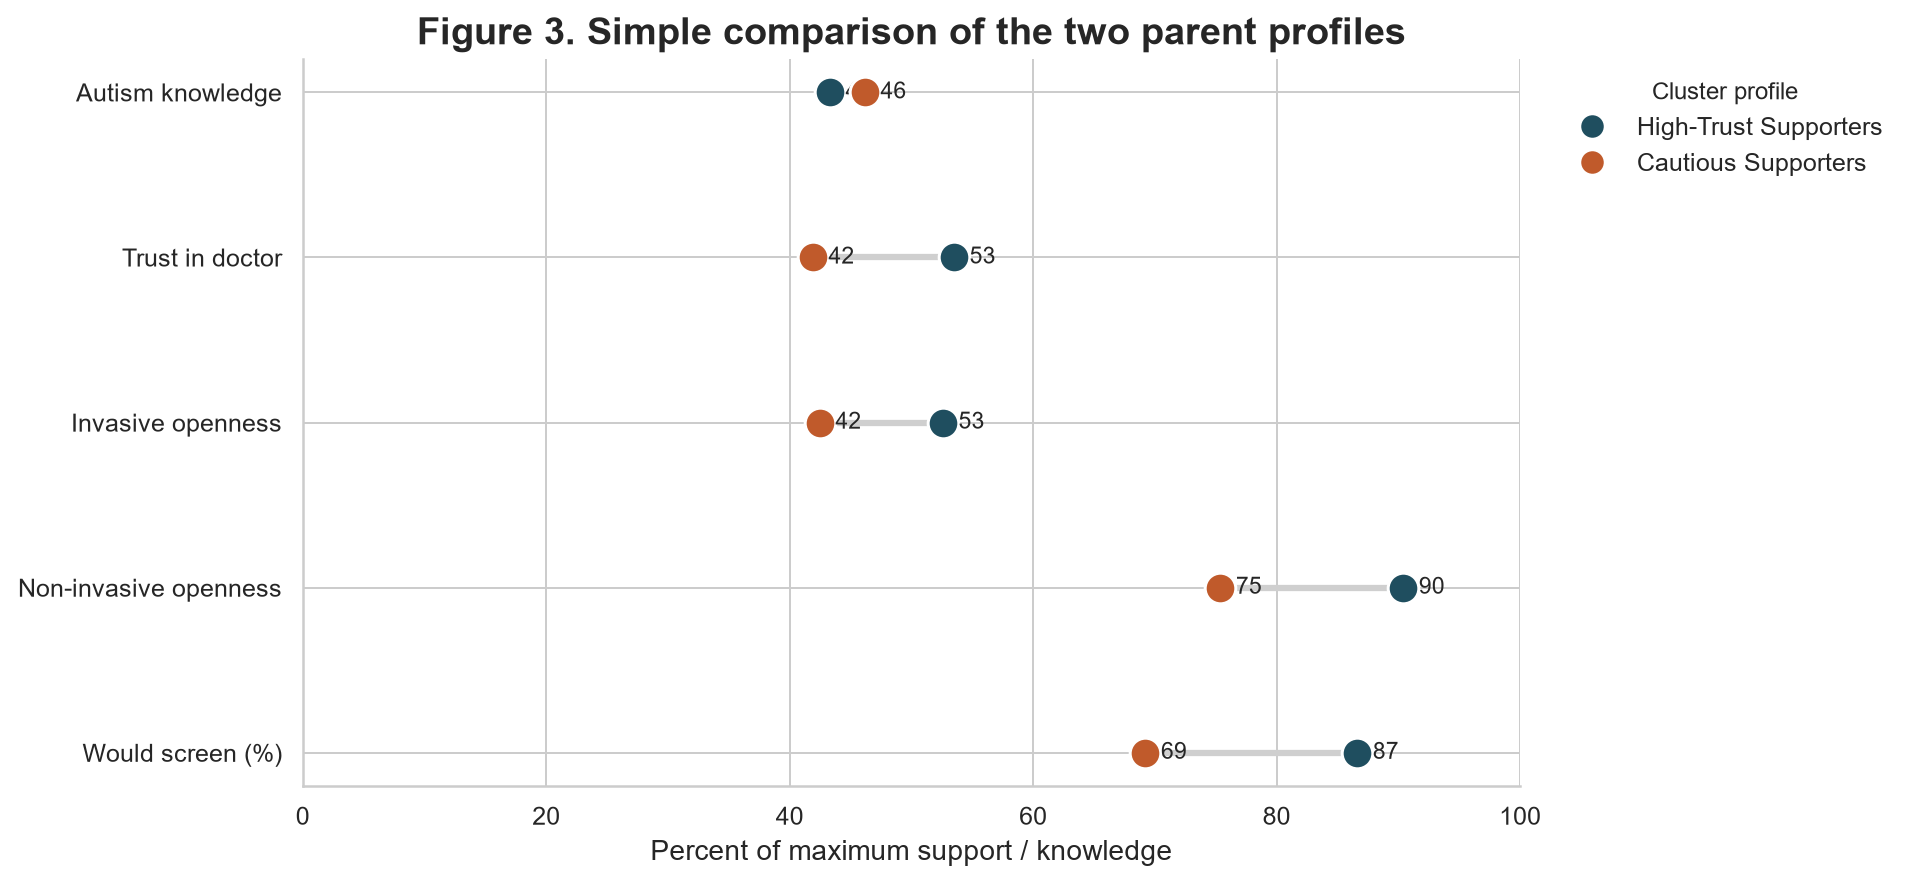

**Figure 3 interpretation.** This simplified comparison shows the same substantive pattern without the clustering jargon: **High-Trust Supporters** are more willing to screen, more open to both non-invasive and invasive modalities, and more trusting of the clinical context. **Cautious Supporters** still lean supportive overall, but their scores are lower on the dimensions that most directly reflect immediate screening acceptance. This figure was exported to the Caregiver Outputs folder as `figure_3_audience_profile_comparison` in both PNG and PDF formats.

In [24]:
audience_profile_df = pd.DataFrame({
    'Cluster': cluster_viz_order,
    'Would screen (%)': cluster_summary_real.set_index('cluster_label').reindex(cluster_viz_order)['screen_yes_rate'].mul(100).values,
    'Non-invasive openness': cluster_viz_df.groupby('cluster_label')[['tfa_video', 'tfa_saliva', 'tfa_observe']].mean().reindex(cluster_viz_order).mean(axis=1).pipe(lambda s: (s - 1) / 6 * 100).values,
    'Invasive openness': cluster_viz_df.groupby('cluster_label')[['tfa_mri', 'tfa_eeg', 'tfa_blood']].mean().reindex(cluster_viz_order).mean(axis=1).pipe(lambda s: (s - 1) / 6 * 100).values,
    'Trust in doctor': cluster_viz_df.groupby('cluster_label')['tfa_trusting'].mean().reindex(cluster_viz_order).pipe(lambda s: (s - 1) / 6 * 100).values,
    'Autism knowledge': cluster_viz_df.groupby('cluster_label')['autism_knowledge_score'].mean().reindex(cluster_viz_order).pipe(lambda s: s / 3 * 100).values,
})
audience_long_df = audience_profile_df.melt(id_vars='Cluster', var_name='Dimension', value_name='Score')
dimension_order = ['Would screen (%)', 'Non-invasive openness', 'Invasive openness', 'Trust in doctor', 'Autism knowledge']
audience_long_df['Dimension'] = pd.Categorical(audience_long_df['Dimension'], categories=dimension_order, ordered=True)

fig3, ax = plt.subplots(figsize=(10.5, 4.8), constrained_layout=True)
for index, dimension in enumerate(dimension_order):
    subset = audience_long_df[audience_long_df['Dimension'] == dimension].copy()
    subset = subset.set_index('Cluster').reindex(cluster_viz_order).reset_index()
    ax.hlines(y=index, xmin=subset['Score'].min(), xmax=subset['Score'].max(), color='#cfcfcf', linewidth=2.5)
    for row in subset.itertuples():
        ax.scatter(row.Score, index, s=150, color=cluster_palette[row.Cluster], edgecolor='white', linewidth=1.2, zorder=3)
        ax.text(row.Score + 1.3, index, f"{row.Score:.0f}", va='center', fontsize=9)

ax.set_yticks(range(len(dimension_order)))
ax.set_yticklabels(dimension_order)
ax.set_xlim(0, 100)
ax.set_xlabel('Percent of maximum support / knowledge')
ax.set_ylabel('')
ax.set_title('Figure 3. Simple comparison of the two parent profiles', fontsize=15, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', label=cluster, markerfacecolor=color, markersize=10)
    for cluster, color in cluster_palette.items()
 ]
ax.legend(handles=legend_handles, title='Cluster profile', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
export_figure(fig3, 'figure_3_audience_profile_comparison')
plt.show()
display(Markdown("**Figure 3 interpretation.** This simplified comparison shows the same substantive pattern without the clustering jargon: **High-Trust Supporters** are more willing to screen, more open to both non-invasive and invasive modalities, and more trusting of the clinical context. **Cautious Supporters** still lean supportive overall, but their scores are lower on the dimensions that most directly reflect immediate screening acceptance. This figure was exported to the Caregiver Outputs folder as `figure_3_audience_profile_comparison` in both PNG and PDF formats."))